Dataset Shape: (690, 16)
  A1     A2     A3 A4 A5 A6 A7    A8 A9 A10  A11 A12 A13    A14  A15 A16
0  b  30.83  0.000  u  g  w  v  1.25  t   t    1   f   g  00202    0   +
1  a  58.67  4.460  u  g  q  h  3.04  t   t    6   f   g  00043  560   +
2  a  24.50  0.500  u  g  q  h  1.50  t   f    0   f   g  00280  824   +
3  b  27.83  1.540  u  g  w  v  3.75  t   t    5   t   g  00100    3   +
4  b  20.17  5.625  u  g  w  v  1.71  t   f    0   f   s  00120    0   +


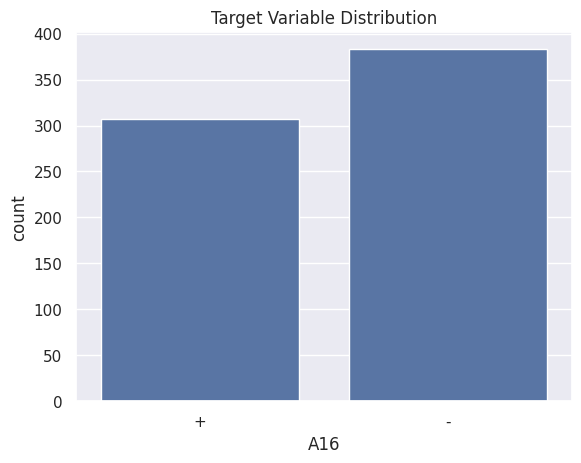

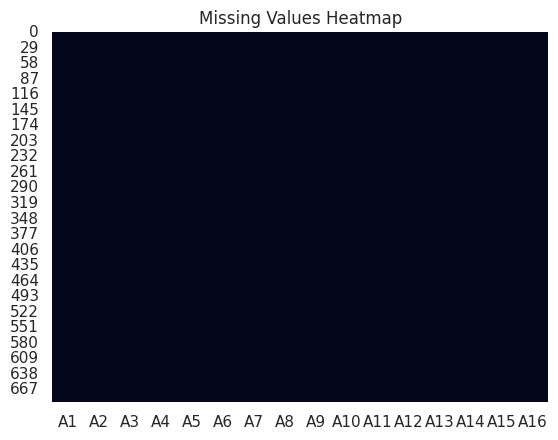

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5421 - loss: 0.7120 - val_accuracy: 0.5573 - val_loss: 0.6865
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6322 - loss: 0.6411 - val_accuracy: 0.6641 - val_loss: 0.6204
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7318 - loss: 0.5850 - val_accuracy: 0.7557 - val_loss: 0.5617
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7912 - loss: 0.5357 - val_accuracy: 0.8015 - val_loss: 0.5119
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8065 - loss: 0.4922 - val_accuracy: 0.8168 - val_loss: 0.4687
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8199 - loss: 0.4545 - val_accuracy: 0.8321 - val_loss: 0.4289
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8372 - loss: 0.4225 - val_accuracy: 0.8244 - val_loss: 0.3953
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8563 - loss: 0.3966 - val_accuracy: 0.8473 - val_loss: 0.368

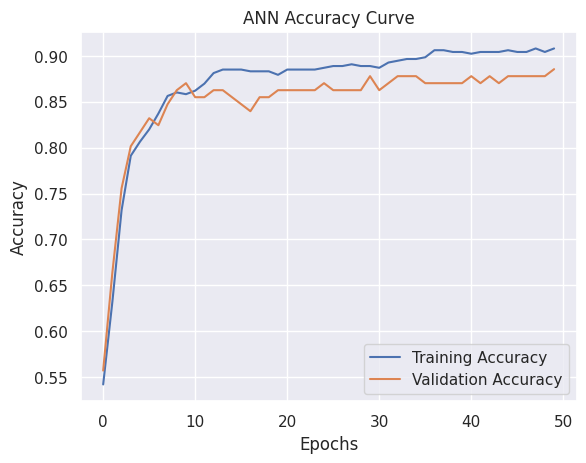

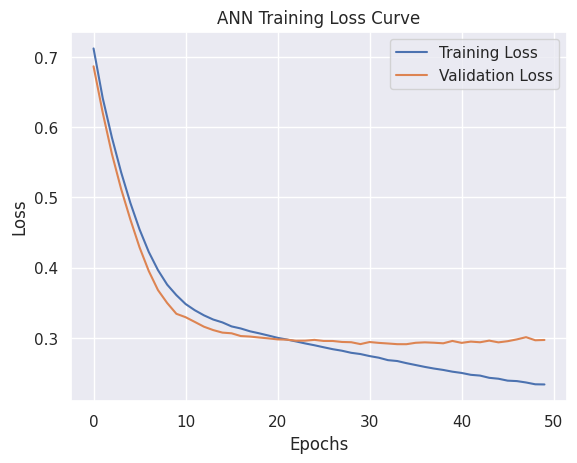

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


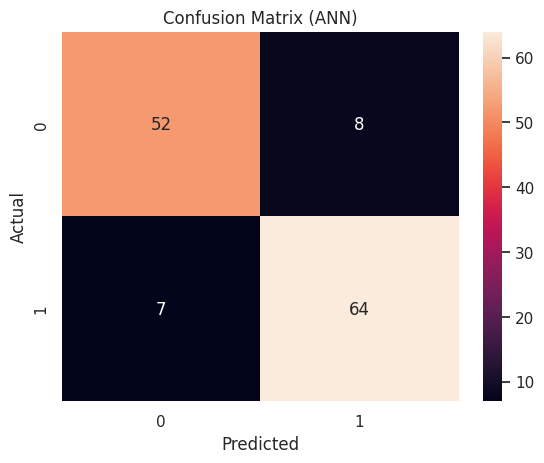

Accuracy: 0.8854961832061069

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.87      0.87        60
           1       0.89      0.90      0.90        71

    accuracy                           0.89       131
   macro avg       0.89      0.88      0.88       131
weighted avg       0.89      0.89      0.89       131



In [2]:
# ================================
# IMPORT LIBRARIES
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

sns.set()

# ================================
# LOAD DATASET
# ================================
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/credit-screening/crx.data"
columns = [f"A{i}" for i in range(1, 17)]
dataset = pd.read_csv(url, header=None, names=columns)

print("Dataset Shape:", dataset.shape)
print(dataset.head())

# ================================
# BASIC EDA (GRAPHS FROM FILE STYLE)
# ================================

# Target distribution
plt.figure()
sns.countplot(x='A16', data=dataset)
plt.title("Target Variable Distribution")
plt.show()

# Missing values heatmap
plt.figure()
sns.heatmap(dataset.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

# ================================
# DATA PREPROCESSING
# ================================

dataset.replace('?', np.nan, inplace=True)
dataset.dropna(inplace=True)

# Separate X and y
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

# Encode categorical columns
for i in range(X.shape[1]):
    if isinstance(X[0, i], str):
        le = LabelEncoder()
        X[:, i] = le.fit_transform(X[:, i])

# Encode target
y = LabelEncoder().fit_transform(y)

# Convert to float
X = X.astype(float)

# ================================
# FEATURE SCALING
# ================================
sc = StandardScaler()
X = sc.fit_transform(X)

# ================================
# TRAIN TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# ================================
# ANN MODEL
# ================================
classifier = Sequential()

classifier.add(Dense(units=16, activation='relu', input_dim=X_train.shape[1]))
classifier.add(Dense(units=8, activation='relu'))
classifier.add(Dense(units=1, activation='sigmoid'))

classifier.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ================================
# TRAIN MODEL
# ================================
history = classifier.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    batch_size=16,
    epochs=50,
    verbose=1
)

# ================================
# 📈 ACCURACY CURVE (COMMON IN FILES)
# ================================
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("ANN Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# ================================
# 📉 LOSS CURVE (REQUIRED)
# ================================
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("ANN Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# ================================
# PREDICTIONS
# ================================
y_pred = classifier.predict(X_test)
y_pred = (y_pred > 0.5)

# ================================
# 📊 CONFUSION MATRIX
# ================================
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (ANN)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ================================
# 📋 PERFORMANCE METRICS
# ================================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))